# Finding proper binary masks

In [12]:
import os


original = '/Users/vlad/Desktop/DALER/2 этап/оригиналы после обрезки/0.png'
output_directory = '/Users/vlad/Desktop/DALER/2 этап/оригиналы после обрезки и preprocessing 2'

filename = os.path.basename(original)
print(filename)

0.png


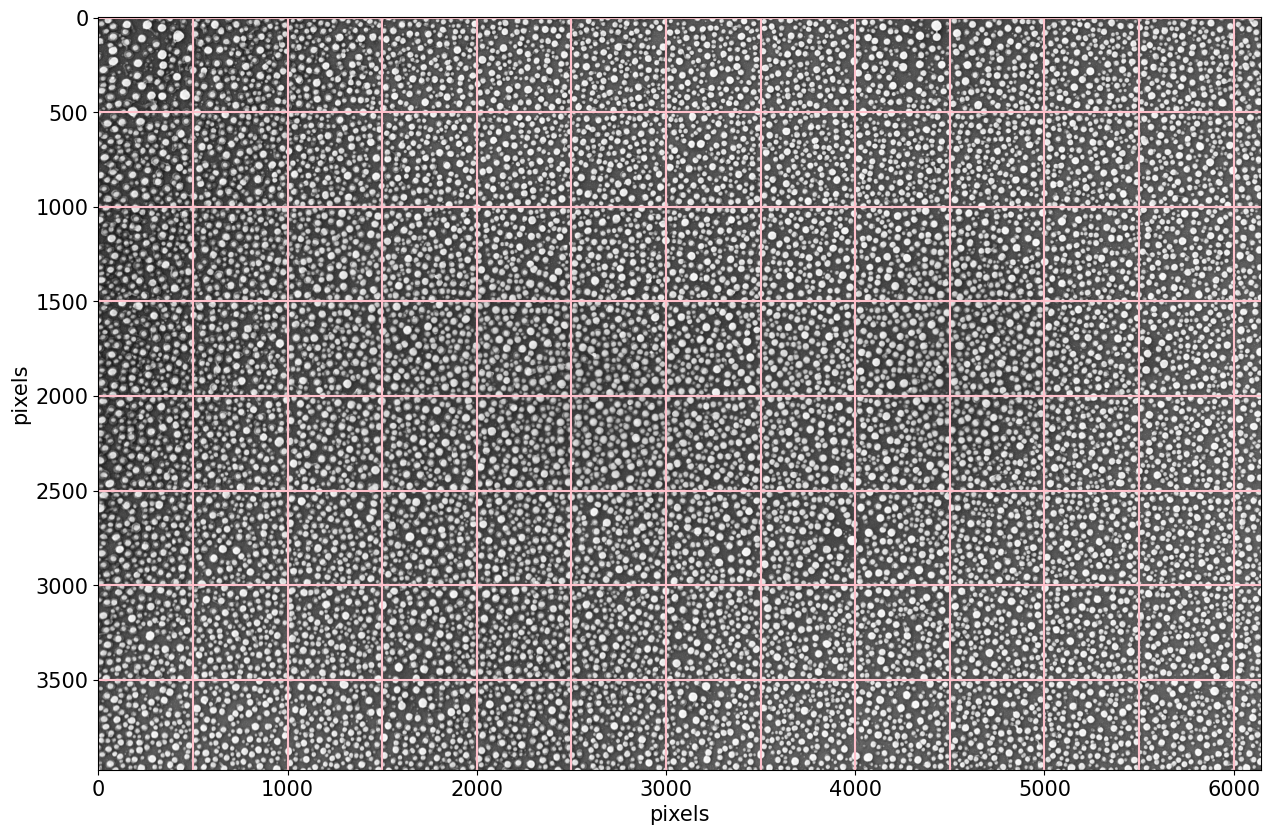

In [13]:
from matplotlib.image import imread
from PIL import Image
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 15,
    "axes.labelsize": 15,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 12,
    "figure.titlesize": 20,
})


img = Image.open(original)
# img.show()
X = np.array(img)


fig = plt.figure(figsize=(15, 15))
plt.imshow(X, cmap = 'gray')
for i in range(13):
    plt.axvline(500 * i, color = 'pink')
for i in range(8):
    plt.axhline(500 * i, color = 'pink')
plt.xlabel('pixels')
plt.ylabel('pixels')
plt.show()




# Correct the illumination

In [14]:
def correct_illumination(img, kernel_size=100):
    """
    Estimate and correct uneven illumination via morphological opening.
    """
    if img.dtype != np.uint8:
        img = (img * 255).astype(np.uint8)
        
    # Large kernel to approximate slow-varying background
    background = cv2.morphologyEx(img, cv2.MORPH_OPEN,
                                  cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size)))
    
    corrected = cv2.subtract(img, background)
    
    # Normalize to 0–255 for visualization
    corrected = cv2.normalize(corrected, None, 0, 255, cv2.NORM_MINMAX)
    
    return corrected, background


img = np.array(Image.open(original))

# Step 1: Correct illumination
corr, bg = correct_illumination(img, kernel_size=200)

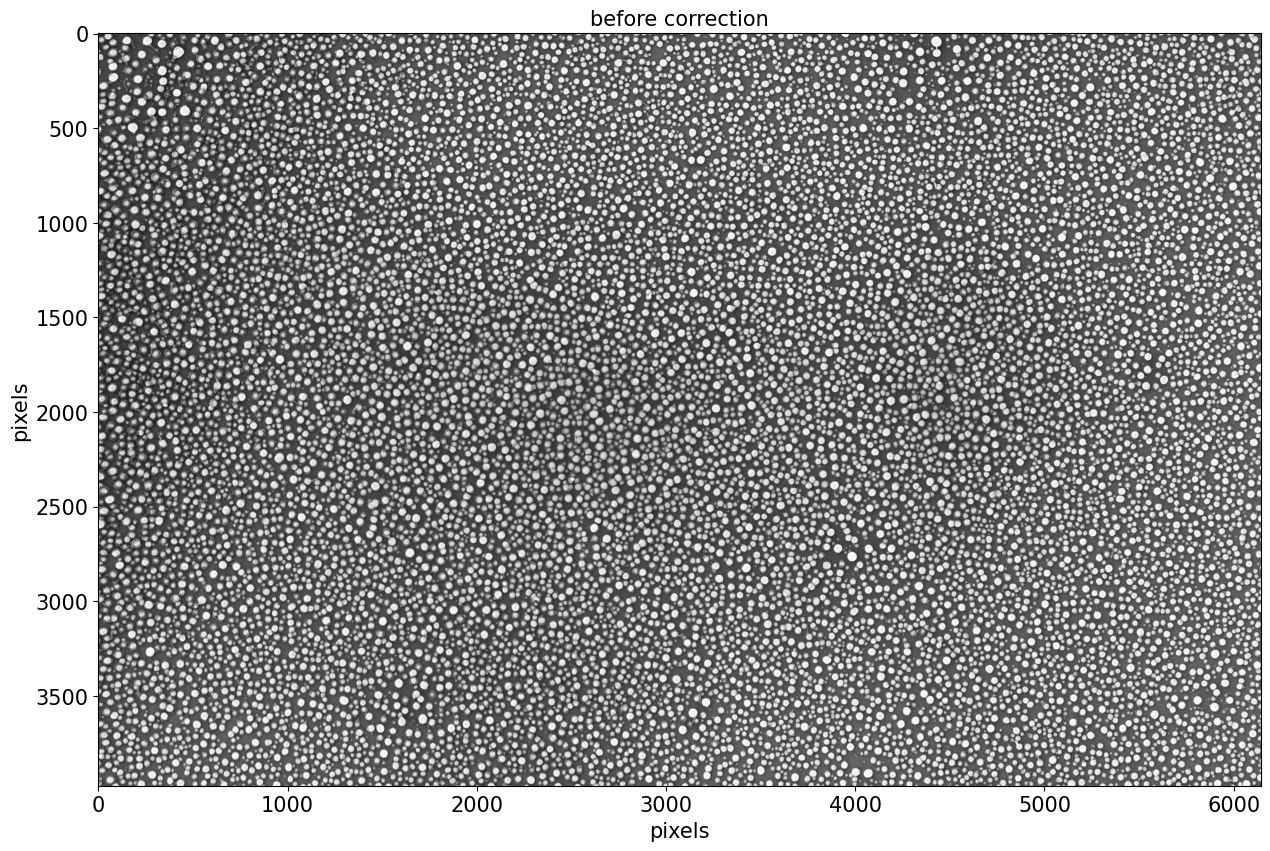

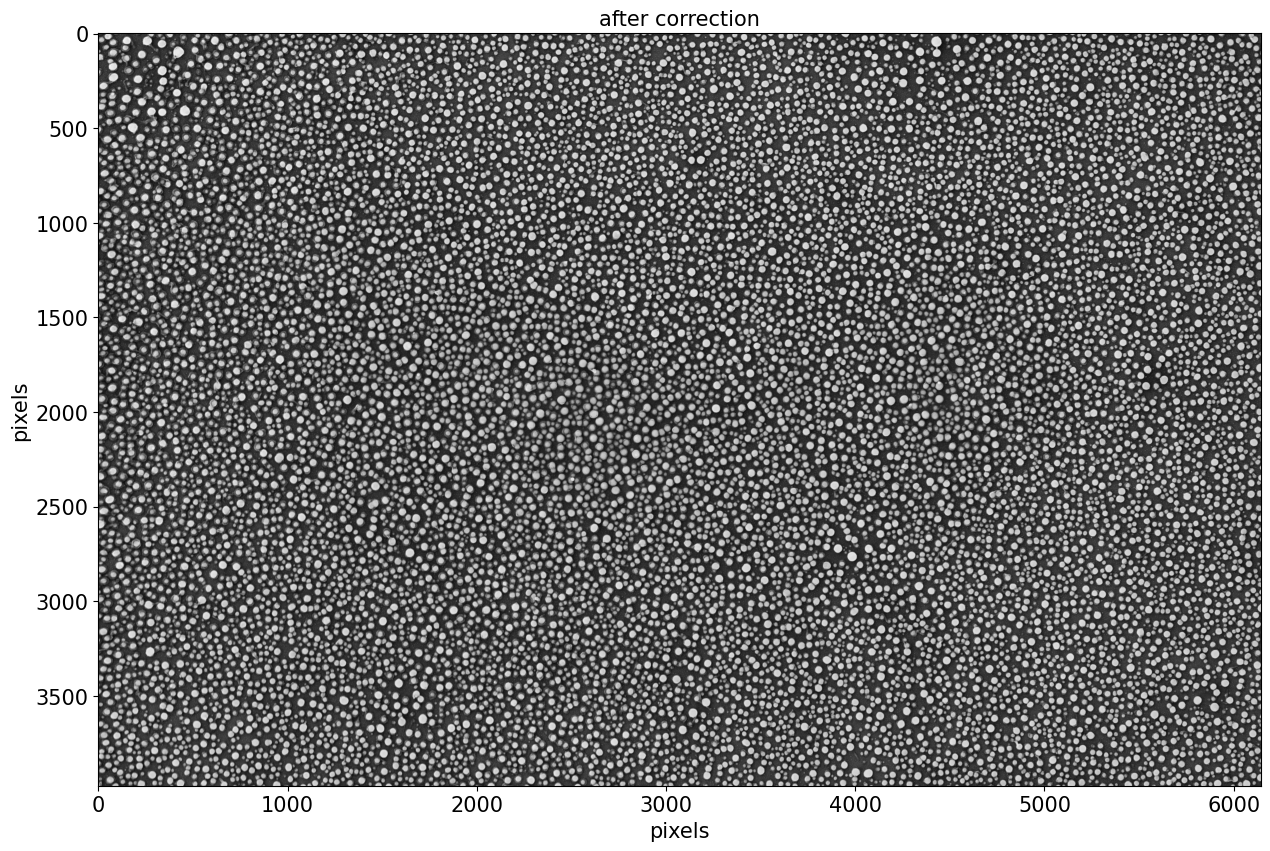

In [15]:
fig = plt.figure(figsize=(15, 15))
plt.imshow(img, cmap = 'gray')

plt.xlabel('pixels')
plt.ylabel('pixels')
plt.title('before correction')
plt.show()


fig = plt.figure(figsize=(15, 15))
plt.imshow(corr, cmap = 'gray')
plt.xlabel('pixels')
plt.ylabel('pixels')
plt.title('after correction')
plt.show()



In [16]:
output_path = os.path.join(output_directory, filename)
cv2.imwrite(output_path, corr)

True